# 1 - Customer Purchase Prediction - Classification

<img src='https://www.skeps.com/hs-fs/hubfs/shutterstock_575822176(1).jpg?width=825&name=shutterstock_575822176(1).jpg'>

Bu çalışmada müşteri davranış verilerini kullanarak bir müşterinin satın alma yapıp yapmayacağını tahmin eden bir classification modeli geliştireceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi inceleme
3. Veri temizleme
4. Feature selection
5. Train-test split
6. Classification modelleri kurma
7. En iyi modeli değerlendirme
8. Örnek tahmin
9. Sonuç

In [1]:
# Gerekli kütüphaneleri kuruyoruz.

In [2]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


## 1. Veriyi Yükleme

In [3]:
# Zip dosyasını Google Drive içinden açıp csv dosyasını çalışma alanına çıkaracağım.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Predict Customer Purchase Behavior Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]

['.config', 'drive', 'customer_purchase_data.csv', 'sample_data']

In [6]:
file_path = '/content/customer_purchase_data.csv'

df = pd.read_csv(file_path)
df.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


## 2. Veriyi Okuma ve İnceleme

In [7]:
# Veri setinin inceleyeceğim.

In [8]:
df.shape

(1500, 9)

In [9]:
df.columns.tolist()

['Age',
 'Gender',
 'AnnualIncome',
 'NumberOfPurchases',
 'ProductCategory',
 'TimeSpentOnWebsite',
 'LoyaltyProgram',
 'DiscountsAvailed',
 'PurchaseStatus']

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB


In [11]:
df.describe()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,44.298667,0.504667,84249.164338,10.420000,2.012667,30.469040,0.326667,2.555333,0.43200
std,15.537259,0.500145,37629.493078,5.887391,1.428005,16.984392,0.469151,1.705152,0.49552
min,18.000000,0.000000,20001.512518,0.000000,0.000000,1.037023,0.000000,0.000000,0.00000
25%,31.000000,0.000000,53028.979155,5.000000,1.000000,16.156700,0.000000,1.000000,0.00000
50%,45.000000,1.000000,83699.581476,11.000000,2.000000,30.939516,0.000000,3.000000,0.00000
75%,57.000000,1.000000,117167.772858,15.000000,3.000000,44.369863,1.000000,4.000000,1.00000
max,70.000000,1.000000,149785.176481,20.000000,4.000000,59.991105,1.000000,5.000000,1.00000


## 3. Veri Temizleme

In [12]:
# Boş veri kontrolü yapacağım ve hedef değişkenin dağılımına bakacağım.

In [13]:
df.isnull().sum()

,0
Age,0
Gender,0
AnnualIncome,0
NumberOfPurchases,0
ProductCategory,0
TimeSpentOnWebsite,0
LoyaltyProgram,0
DiscountsAvailed,0
PurchaseStatus,0


In [14]:
df['PurchaseStatus'].value_counts()

,count
PurchaseStatus,
0,852
1,648


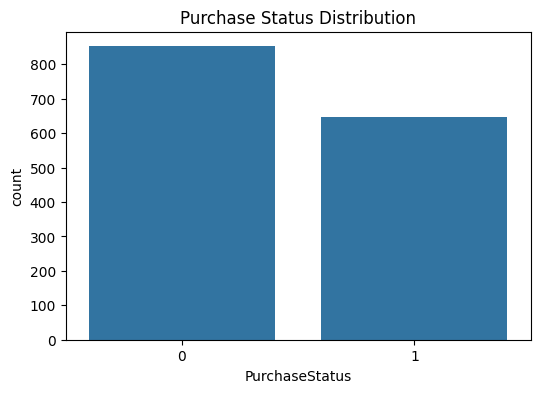

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x='PurchaseStatus', data=df)
plt.title('Purchase Status Distribution')
plt.show()

## 4. Feature Selection

In [16]:
# Satın alma durumu dışındaki sütunları giriş değişkeni olarak kullanacağım.

In [17]:
x = df.drop('PurchaseStatus', axis=1)
y = df['PurchaseStatus']

x.head()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed
0,40,1,66120.267939,8,0,30.568601,0,5
1,20,1,23579.773583,4,2,38.240097,0,5
2,27,1,127821.306432,11,2,31.633212,1,0
3,24,1,137798.623120,19,3,46.167059,0,4
4,31,1,99300.964220,19,1,19.823592,0,0


## 5. Train-Test Split

In [18]:
# Veriyi eğitim ve test olarak ayıracağım.

In [19]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

x_train.shape, x_test.shape

((1200, 8), (300, 8))

## 6. Classification Modelleri Kurma

In [20]:
# Bu bölümde birkaç farklı classification modeli kurup sonuçları karşılaştıracağım.

In [21]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, accuracy, f1])
    trained_models[name] = model

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'F1'])
results_df.sort_values(by='F1', ascending=False)

,Model,Accuracy,F1
3,Gradient Boosting,0.936667,0.924901
2,Random Forest,0.926667,0.914729
4,Extra Trees,0.920000,0.906250
1,KNN,0.850000,0.830189
0,Logistic Regression,0.826667,0.792000


## 7. En İyi Modeli Değerlendirme

In [23]:
best_model_name = results_df.sort_values(by='F1', ascending=False).iloc[0]['Model']
best_model = trained_models[best_model_name]
best_pred = best_model.predict(x_test)

print('Best Model:', best_model_name)
print('Accuracy:', accuracy_score(y_test, best_pred))
print('F1 Score:', f1_score(y_test, best_pred))
print(classification_report(y_test, best_pred))

Best Model: Gradient Boosting
Accuracy: 0.9366666666666666
F1 Score: 0.924901185770751
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       170
           1       0.95      0.90      0.92       130

    accuracy                           0.94       300
   macro avg       0.94      0.93      0.94       300
weighted avg       0.94      0.94      0.94       300



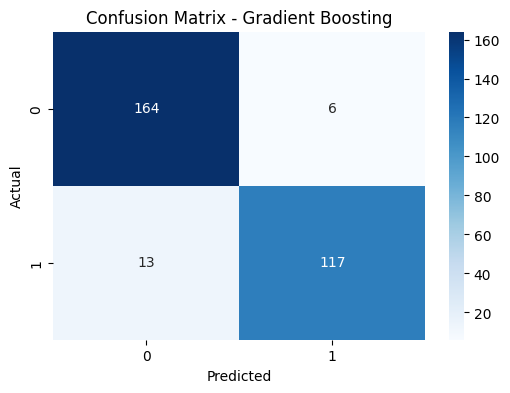

In [24]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 8. Örnek Tahmin

In [25]:
# Bu bölümde örnek bir müşteri verisi için satın alma tahmini yapacağım.

In [26]:
sample_customer = x_test.iloc[[0]]
sample_prediction = best_model.predict(sample_customer)[0]

print('Tahmin edilen satın alma durumu:', sample_prediction)
print('Gerçek değer:', y_test.iloc[0])

Tahmin edilen satın alma durumu: 0
Gerçek değer: 0


## 9. Sonuç

In [27]:
# Bu bölümde en iyi modeli yorumlayıp genel sonucu özetleyeceğim.

In [28]:
best_accuracy = results_df.sort_values(by='F1', ascending=False).iloc[0]['Accuracy']
best_f1 = results_df.sort_values(by='F1', ascending=False).iloc[0]['F1']

print(f"Bu projede en başarılı model: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"F1 Score: {best_f1:.4f}")
print('Bu sonuca göre müşteri satın alma tahmininde en iyi performansı bu model verdi.')

Bu projede en başarılı model: Gradient Boosting
Accuracy: 0.9367
F1 Score: 0.9249
Bu sonuca göre müşteri satın alma tahmininde en iyi performansı bu model verdi.


Bu çalışmada müşterinin satın alma durumu tahmin edildi. En başarılı sonuç Gradient Boosting modeli 0.9367 ile elde edildi.